## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**Mistral-small3.1** was tasked with generating a **couch** using the **SPOMSO** package. The model was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

To design a couch using the SPOMSO Python package, we'll create various components of the couch such as the seat, backrest, armrests, and legs. We'll then combine these components using the `CombineGeometry` class to create the final couch model. Finally, we'll generate the point cloud and visualizations.

Here's the Python code to achieve this:

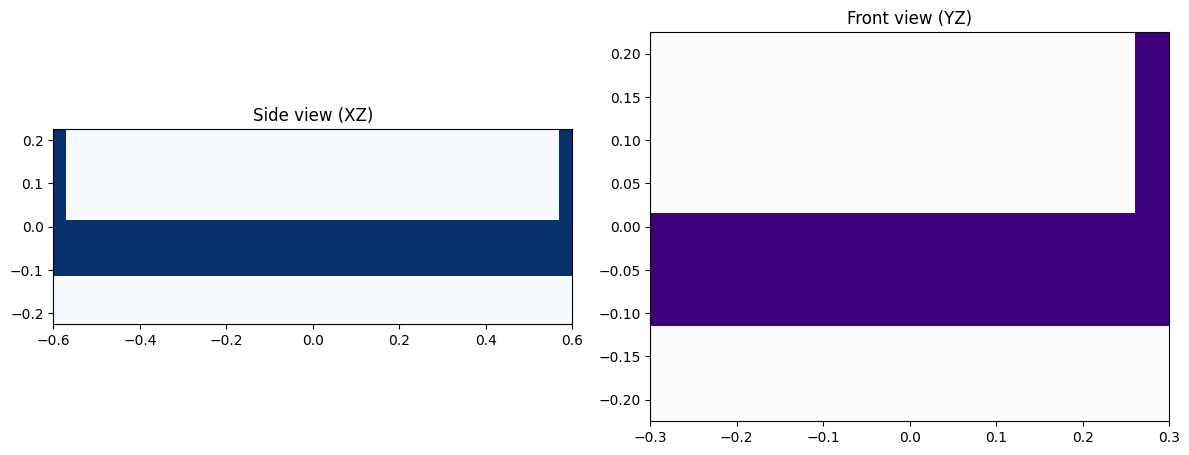

Point cloud saved: 56,849 points


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box, Cylinder
from spomso.cores.combine import CombineGeometry

# Define the dimensions and resolution for the couch
couch_size = (1.2, 0.6, 0.45)  # Width, Depth, Height
resolution = (120, 60, 45)

# Generate the coordinate grid
coor, res = generate_grid(couch_size, resolution)

# Create the seat
seat = Box(1.2, 0.6, 0.1)
seat.rounding(0.02)
seat.move((0, 0, -0.05))

# Create the backrest
backrest = Box(1.2, 0.02, 0.4)
backrest.rounding(0.02)
backrest.move((0, 0.3, 0.15))

# Create the armrests
left_armrest = Box(0.02, 0.6, 0.4)
left_armrest.rounding(0.02)
left_armrest.move((-0.6, 0, 0.15))

right_armrest = Box(0.02, 0.6, 0.4)
right_armrest.rounding(0.02)
right_armrest.move((0.6, 0, 0.15))

# Create the legs
leg_positions = [
    (-0.55, -0.25, -0.1),
    (-0.55, 0.25, -0.1),
    (0.55, -0.25, -0.1),
    (0.55, 0.25, -0.1)
]

legs = []
for pos in leg_positions:
    leg = Cylinder(0.03, 0.1)
    leg.rounding(0.01)
    leg.move(pos)
    legs.append(leg)

# Combine all parts to form the couch
couch = CombineGeometry("UNION").combine(seat, backrest, left_armrest, right_armrest, *legs)

# Generate the signed distance field (SDF)
sdf = couch.create(coor)

# Convert SDF to binary field and reshape
binary_3d = smarter_reshape(hard_binarization(sdf, 0), resolution)

# Plot the cross-sections
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(binary_3d[:, resolution[1]//2, :].T,
              cmap="Blues", origin="lower",
              extent=(-couch_size[0]/2, couch_size[0]/2, -couch_size[2]/2, couch_size[2]/2))
axes[0].set_title("Side view (XZ)")

axes[1].imshow(binary_3d[resolution[0]//2, :, :].T,
              cmap="Purples", origin="lower",
              extent=(-couch_size[1]/2, couch_size[1]/2, -couch_size[2]/2, couch_size[2]/2))
axes[1].set_title("Front view (YZ)")
plt.tight_layout()
plt.show()

# Generate the surface point cloud
dx = couch_size[0] / resolution[0]
surface_pts = coor[:, np.abs(sdf) < dx * 1.5].T
np.save("couch_surface.npy", surface_pts)
print(f"Point cloud saved: {surface_pts.shape[0]:,} points")

### Explanation:
1. **Dimensions and Resolution**: We define the dimensions of the couch and the resolution for the coordinate grid.
2. **Coordinate Grid**: We generate the coordinate grid using `generate_grid`.
3. **Components**:
   - **Seat**: A box representing the seating area.
   - **Backrest**: A thin box representing the backrest.
   - **Armrests**: Thin boxes representing the armrests.
   - **Legs**: Cylinders representing the legs of the couch.
4. **Combine Geometry**: We combine all the components using `CombineGeometry` with the "UNION" operation.
5. **Signed Distance Field (SDF)**: We generate the SDF for the couch.
6. **Binary Field and Cross-Sections**: We convert the SDF to a binary field and plot cross-sections.
7. **Surface Point Cloud**: We extract the surface points and save them to a file.

This code will output the point cloud of the couch and generate plots showing the side and front views of the couch. The plots will maintain true proportions of the object.

**End response**

**Approximate time**: 21s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=hard_binarization(sdf, 0),
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()